# BTC Perpetual Futures — Wavelet Jump Classification & Probabilistic Price Forecasting
**Target Exchange**: Binance USDM Futures (BTCUSDT Perpetual)  
**Phase 1 — Research Pipeline**: Data collection → Jump labelling → Feature matrix → Calibration validation  
**No execution logic in this notebook.**

---
## SECTION 0 — Imports & Environment Setup

In [76]:
!pip install structlog
!pip install hmmlearn

In [77]:
# ── Standard library ──────────────────────────────────────────────────────────
import asyncio
import json
import logging
import os
import time
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# ── Third-party ───────────────────────────────────────────────────────────────
import aiohttp
import hdbscan
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pywt
import scipy.stats as stats
import structlog
from hmmlearn.hmm import GaussianHMM
from sklearn.calibration import calibration_curve
from sklearn.ensemble import IsolationForest
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Logging ───────────────────────────────────────────────────────────────────
structlog.configure(
    processors=[
        structlog.stdlib.add_log_level,
        structlog.stdlib.PositionalArgumentsFormatter(),
        structlog.dev.ConsoleRenderer(),
    ],
    wrapper_class=structlog.BoundLogger,
    context_class=dict,
    logger_factory=structlog.PrintLoggerFactory(),
)
log = structlog.get_logger()

print("Environment loaded successfully.")

Environment loaded successfully.


---
## SECTION 16 — Configuration (settings.py)
All constants live here. No magic numbers anywhere else in the notebook.

In [78]:
@dataclass(frozen=True)
class Config:
    # Exchange
    SYMBOL:                str   = "BTCUSDT"
    BASE_URL:              str   = "https://fapi.binance.us"
    TESTNET_URL:           str   = "https://testnet.binancefuture.us"
    WS_BASE_URL:           str   = "wss://fstream.binance.com"

    # Rate limiting
    WEIGHT_LIMIT_1M:       int   = 2400
    WEIGHT_SAFETY_PCT:     float = 0.80       # Never exceed 80% = 1920 / 2400
    BACKOFF_BASE_MS:       int   = 200        # First retry wait in ms
    MAX_RETRIES:           int   = 5

    # Jump detection
    JUMP_SIGMA_WINDOW:     int   = 120        # Bars for local vol estimation
    JUMP_THRESHOLD:        float = 4.0        # Gumbel threshold (4 std devs)
    JUMP_CLUSTER_GAP:      int   = 5          # Bars to suppress after a jump
    PRE_JUMP_WINDOW:       int   = 30         # Bars before jump for features
    POST_JUMP_WINDOW:      int   = 60         # Bars after jump (1-hour bucket)

    # Wavelet
    WAVELET_J:             int   = 6          # Number of scales
    WAVELET_NAME:          str   = "cmor1.5-1.0"

    # CVD
    CVD_SLOPE_WINDOW:      int   = 15         # Bars for CVD slope computation
    CVD_DIVERGENCE_WINDOW: int   = 15         # Bars for price-CVD correlation

    # Regime
    MACRO_HMM_STATES:      int   = 4
    MACRO_HMM_RETRAIN_DAYS:int   = 30
    MACRO_LOOKBACK_DAYS:   int   = 365
    MICRO_EFF_WINDOW:      int   = 30         # Bars for efficiency ratio
    MICRO_EFF_TREND_THRESH:float = 0.35
    MICRO_EFF_RANGE_THRESH:float = 0.15

    # Volume profile
    VOL_PROFILE_BINS:      int   = 200        # Price levels in histogram
    VOL_PROFILE_VA_PCT:    float = 0.70       # Value area = 70% of volume

    # Dataset splits (inclusive date ranges)
    TRAIN_START:           str   = "2021-01-01"
    TRAIN_END:             str   = "2022-12-31"
    VAL_START:             str   = "2023-01-01"
    VAL_END:               str   = "2023-06-30"
    TEST_START:            str   = "2023-07-01"
    TEST_END:              str   = "2024-12-31"

    # Calibration success thresholds
    TARGET_BRIER_SCORE:    float = 0.20       # Below this = acceptable
    TARGET_ECE:            float = 0.05       # Below this = calibrated
    TARGET_DIRECTIONAL_ACC:float = 0.55       # Above this = better than random


CONFIG = Config()
print(f"Config loaded: symbol={CONFIG.SYMBOL}, jump_threshold={CONFIG.JUMP_THRESHOLD}")

Config loaded: symbol=BTCUSDT, jump_threshold=4.0


---
## SECTION 1 — Project Objective
This section documents the research question and validates that all required libraries are importable.

In [79]:
# ── Objective summary ─────────────────────────────────────────────────────────
import importlib.metadata as md
OBJECTIVE = """
Build a quantitative research system that:
  1. Collects 1-minute BTCUSDT perpetual futures data from Binance
     (OHLCV, delta, open interest, funding rate, liquidations)
  2. Detects price jumps on 1-minute bars using a Gumbel-threshold
     statistical test derived from Aubrun, Morel, Benzaquen, Bouchaud (PNAS 2025)
  3. Classifies each jump: endogenous | exogenous | anticipatory
     using wavelet scattering coefficients
  4. Enriches each jump event with microstructure features
  5. Constructs a feature matrix (one row = one jump event)
  6. Trains LightGBM + Gaussian Process to predict the
     probability distribution of the next 1-hour price move
  7. Validates calibration (Brier Score + ECE) on a held-out test set

Success criteria:
  - Brier Score < 0.20  (across all classes)
  - ECE         < 0.05  (at least 3 of 5 classes)
  - Directional accuracy > 55%
"""
print(OBJECTIVE)

def get_version(pkg):
    try:
        return md.version(pkg)
    except:
        return "unknown"

# ── Library check ─────────────────────────────────────────────────────────────
"""
required = [
    ("aiohttp",     aiohttp.__version__),
    ("numpy",       np.__version__),
    ("pandas",      pd.__version__),
    ("pywt",        pywt.__version__),
    ("lightgbm",    lgb.__version__),
    ("hdbscan",     hdbscan.__version__),
]
"""

required = [
    ("aiohttp",     get_version("aiohttp")),
    ("numpy",       get_version("numpy")),
    ("pandas",      get_version("pandas")),
    ("pywt",        get_version("PyWavelets")),
    ("lightgbm",    get_version("lightgbm")),
    ("hdbscan",     get_version("hdbscan")),
]
print("Library versions:")
for name, ver in required:
    print(f"  {name:<15} {ver}")


Build a quantitative research system that:
  1. Collects 1-minute BTCUSDT perpetual futures data from Binance
     (OHLCV, delta, open interest, funding rate, liquidations)
  2. Detects price jumps on 1-minute bars using a Gumbel-threshold
     statistical test derived from Aubrun, Morel, Benzaquen, Bouchaud (PNAS 2025)
  3. Classifies each jump: endogenous | exogenous | anticipatory
     using wavelet scattering coefficients
  4. Enriches each jump event with microstructure features
  5. Constructs a feature matrix (one row = one jump event)
  6. Trains LightGBM + Gaussian Process to predict the
     probability distribution of the next 1-hour price move
  7. Validates calibration (Brier Score + ECE) on a held-out test set

Success criteria:
  - Brier Score < 0.20  (across all classes)
  - ECE         < 0.05  (at least 3 of 5 classes)
  - Directional accuracy > 55%

Library versions:
  aiohttp         3.13.4
  numpy           2.0.2
  pandas          2.2.2
  pywt            1.9.0
  li

---
## SECTION 2 — System Architecture
Six-layer architecture. Build in strict order. No skipping ahead.

In [80]:
ARCHITECTURE = """
┌─────────────────────────────────────────────────────────────────┐
│  LAYER 0 — RAW DATA INGESTION                                   │
│  Binance USDM Futures REST API + WebSocket Streams              │
│  Instruments: BTCUSDT perpetual only                            │
│  Resolution: 1-minute bars as primary, tick-level for delta     │
│  Coverage: Jan 2021 → present (3+ years minimum)               │
└──────────────────────────┬──────────────────────────────────────┘
                           │
┌──────────────────────────▼──────────────────────────────────────┐
│  LAYER 1 — RATE LIMIT MANAGER                                   │
│  Central throttle. Reads response headers after every request.  │
│  Tracks used weight, remaining weight, ban state.               │
│  Never exceeds 80% of limit (1920 / 2400 weight per minute).   │
└──────────────────────────┬──────────────────────────────────────┘
                           │
┌──────────────────────────▼──────────────────────────────────────┐
│  LAYER 2 — STORAGE ENGINE                                       │
│  TimescaleDB: 1-min OHLCV, OI, CVD time series (append-only)   │
│  Redis: Rolling state, current regime, active pipeline state    │
│  Parquet: Historical batch exports, feature matrix, artifacts   │
└──────────────────────────┬──────────────────────────────────────┘
                           │
┌──────────────────────────▼──────────────────────────────────────┐
│  LAYER 3 — FEATURE ENGINE                                       │
│  Jump detection → extract 30-bar pre-jump window                │
│  Wavelet features (pre-jump only, never post-jump)              │
│  CVD slope + divergence from price                              │
│  OI change character (conviction vs liquidation)                │
│  Volume profile distances (daily / weekly / monthly)            │
│  Two-level regime state (macro HMM + micro efficiency ratio)    │
│  Isolation Forest anomaly score                                 │
└──────────────────────────┬──────────────────────────────────────┘
                           │
┌──────────────────────────▼──────────────────────────────────────┐
│  LAYER 4 — ML STACK                                             │
│  Macro HMM: 4-state regime detector (daily cadence)            │
│  HDBSCAN: cluster exploration (research only, not live)        │
│  LightGBM: jump type probabilities P(endo/exo/anticip)         │
│  Gaussian Process: same + uncertainty estimate                  │
└──────────────────────────┬──────────────────────────────────────┘
                           │
┌──────────────────────────▼──────────────────────────────────────┐
│  LAYER 5 — PROBABILITY FORECASTER + CALIBRATION VALIDATOR       │
│  Target: probability distribution of next 1-hour return         │
│  Output buckets: strong_up / mild_up / flat / mild_down /       │
│                  strong_down                                    │
│  Validation metric: Brier Score + Expected Calibration Error    │
│  Dataset split: strict temporal, never random                   │
└─────────────────────────────────────────────────────────────────┘
"""
print(ARCHITECTURE)


┌─────────────────────────────────────────────────────────────────┐
│  LAYER 0 — RAW DATA INGESTION                                   │
│  Binance USDM Futures REST API + WebSocket Streams              │
│  Instruments: BTCUSDT perpetual only                            │
│  Resolution: 1-minute bars as primary, tick-level for delta     │
│  Coverage: Jan 2021 → present (3+ years minimum)               │
└──────────────────────────┬──────────────────────────────────────┘
                           │
┌──────────────────────────▼──────────────────────────────────────┐
│  LAYER 1 — RATE LIMIT MANAGER                                   │
│  Central throttle. Reads response headers after every request.  │
│  Tracks used weight, remaining weight, ban state.               │
│  Never exceeds 80% of limit (1920 / 2400 weight per minute).   │
└──────────────────────────┬──────────────────────────────────────┘
                           │
┌──────────────────────────▼───────────────────────────────

---
## SECTION 3 — Data Sources & Rate Limit Manager
**Step 1 of build order.** REST client + rate limiter. Verify: can fetch klines, prints credit summary correctly.

In [81]:
# ── Rate limit state ──────────────────────────────────────────────────────────
@dataclass
class RateLimitState:
    """Tracks Binance API weight consumption and ban state."""
    used_1m: int = 0
    used_1h: int = 0
    limit_1m: int = CONFIG.WEIGHT_LIMIT_1M
    limit_1h: int = 100_000          # Binance does not publish an official 1h limit
    ban_until: Optional[float] = None
    request_count: int = 0
    ban_events: int = 0
    run_start: float = field(default_factory=time.time)

    @property
    def safety_ceiling(self) -> int:
        return int(self.limit_1m * CONFIG.WEIGHT_SAFETY_PCT)

    @property
    def is_banned(self) -> bool:
        return self.ban_until is not None and time.time() < self.ban_until

    def update_from_headers(self, headers: dict) -> None:
        """Parse and store weight values from every API response."""
        if "X-MBX-USED-WEIGHT-1M" in headers:
            self.used_1m = int(headers["X-MBX-USED-WEIGHT-1M"])
        if "X-MBX-USED-WEIGHT-1H" in headers:
            self.used_1h = int(headers["X-MBX-USED-WEIGHT-1H"])
        self.request_count += 1

    def print_summary(self) -> None:
        """Print API credit summary after a collection run."""
        elapsed = time.time() - self.run_start
        remaining = self.limit_1m - self.used_1m
        pct_free = remaining / self.limit_1m * 100
        if self.used_1m / self.limit_1m > 0.85:
            status = "CRITICAL"
        elif self.used_1m / self.limit_1m > 0.70:
            status = "WARNING"
        else:
            status = "OK"
        print(
            f"\n{'=' * 50}\n"
            f"  PIPELINE COMPLETE — API CREDIT SUMMARY\n"
            f"{'=' * 50}\n"
            f"  Weight used (1m):    {self.used_1m} / {self.limit_1m}\n"
            f"  Weight remaining:    {remaining}  ({pct_free:.1f}% free)\n"
            f"  Weight used (1h):    {self.used_1h} / {self.limit_1h}\n"
            f"  Requests this run:   {self.request_count}\n"
            f"  Elapsed:             {elapsed:.1f}s\n"
            f"  Ban events:          {self.ban_events}\n"
            f"  Status: {status}\n"
            f"{'=' * 50}\n"
        )


# ── Async REST client ─────────────────────────────────────────────────────────
class BinanceFuturesClient:
    """
    Async REST client for Binance USDM Futures.
    Reads rate limit headers on every response and enforces
    the 80% safety ceiling automatically.
    """

    def __init__(self, base_url: str = CONFIG.BASE_URL) -> None:
        self.base_url = base_url
        self.state = RateLimitState(run_start=time.time())
        self._session: Optional[aiohttp.ClientSession] = None

    async def _get_session(self) -> aiohttp.ClientSession:
        if self._session is None or self._session.closed:
            self._session = aiohttp.ClientSession()
        return self._session

    async def close(self) -> None:
        if self._session and not self._session.closed:
            await self._session.close()

    async def _request(
        self,
        endpoint: str,
        params: dict,
        weight: int = 1,
    ) -> Optional[dict | list]:
        """Make a single GET request. Handles 429, 418, 503 status codes."""
        # ── Ban check ──────────────────────────────────────────────────────
        if self.state.is_banned:
            wait = self.state.ban_until - time.time()
            log.warning("ip_banned", wait_seconds=round(wait, 1))
            await asyncio.sleep(wait)

        # ── Safety ceiling ─────────────────────────────────────────────────
        if self.state.used_1m + weight > self.state.safety_ceiling:
            log.warning(
                "approaching_rate_limit",
                used=self.state.used_1m,
                ceiling=self.state.safety_ceiling,
            )
            await asyncio.sleep(5)  # back off and let the window reset

        session = await self._get_session()
        url = f"{self.base_url}{endpoint}"
        backoff_ms = CONFIG.BACKOFF_BASE_MS

        for attempt in range(CONFIG.MAX_RETRIES):
            try:
                async with session.get(url, params=params) as resp:
                    self.state.update_from_headers(dict(resp.headers))

                    if resp.status == 200:
                        return await resp.json()

                    elif resp.status == 429:
                        retry_after = int(resp.headers.get("Retry-After", 1))
                        log.warning("rate_limited_429", retry_after=retry_after)
                        await asyncio.sleep(retry_after + 1)

                    elif resp.status == 418:
                        self.state.ban_until = time.time() + 120
                        self.state.ban_events += 1
                        log.error("ip_banned_418", duration_seconds=120)
                        await asyncio.sleep(120)

                    elif resp.status == 503:
                        wait_s = backoff_ms / 1000
                        log.warning("service_unavailable_503", backoff_s=wait_s, attempt=attempt)
                        await asyncio.sleep(wait_s)
                        backoff_ms = min(backoff_ms * 2, 3200)

                    else:
                        log.error("unexpected_status", status=resp.status)
                        return None

            except aiohttp.ClientError as exc:
                log.error("request_failed", error=str(exc), attempt=attempt)
                await asyncio.sleep(backoff_ms / 1000)
                backoff_ms = min(backoff_ms * 2, 3200)

        log.error("max_retries_exceeded", endpoint=endpoint)
        return None

    # ── Public methods ─────────────────────────────────────────────────────
    async def get_klines(
        self,
        symbol: str,
        interval: str,
        start_ms: int,
        end_ms: Optional[int] = None,
        limit: int = 1500,
    ) -> Optional[list]:
        """Fetch kline / OHLCV bars. Weight = 5."""
        params: dict = {"symbol": symbol, "interval": interval, "limit": limit,
                        "startTime": start_ms}
        if end_ms:
            params["endTime"] = end_ms
        return await self._request("/fapi/v1/klines", params, weight=5)

    async def get_agg_trades(
        self,
        symbol: str,
        start_ms: int,
        end_ms: int,
        limit: int = 1000,
    ) -> Optional[list]:
        """Fetch aggregate trades for delta computation. Weight = 20."""
        params = {"symbol": symbol, "startTime": start_ms, "endTime": end_ms,
                  "limit": limit}
        return await self._request("/fapi/v1/aggTrades", params, weight=20)

    async def get_open_interest(self, symbol: str) -> Optional[dict]:
        """Fetch current OI snapshot. Weight = 1."""
        return await self._request("/fapi/v1/openInterest", {"symbol": symbol}, weight=1)

    async def get_open_interest_hist(
        self,
        symbol: str,
        period: str = "5m",
        start_ms: Optional[int] = None,
        limit: int = 500,
    ) -> Optional[list]:
        """Fetch historical OI at 5-min resolution. Weight = 1."""
        params: dict = {"symbol": symbol, "period": period, "limit": limit}
        if start_ms:
            params["startTime"] = start_ms
        return await self._request("/futures/data/openInterestHist", params, weight=1)

    async def get_funding_rate(
        self,
        symbol: str,
        start_ms: Optional[int] = None,
        limit: int = 1000,
    ) -> Optional[list]:
        """Fetch funding rate history (8-hour cadence). Weight = 1."""
        params: dict = {"symbol": symbol, "limit": limit}
        if start_ms:
            params["startTime"] = start_ms
        return await self._request("/fapi/v1/fundingRate", params, weight=1)


# ── Historical loader ─────────────────────────────────────────────────────────
class HistoricalLoader:
    """
    Downloads BTCUSDT 1-min klines from Jan 2021 to present
    while staying within rate limits. Paginates automatically.
    """

    def __init__(self, client: BinanceFuturesClient) -> None:
        self.client = client

    @staticmethod
    def _klines_to_df(raw: list) -> pd.DataFrame:
        """Convert Binance kline list-of-lists to a typed DataFrame."""
        cols = ["open_time", "open", "high", "low", "close", "volume",
                "close_time", "quote_vol", "n_trades", "taker_buy_base",
                "taker_buy_quote", "ignore"]
        df = pd.DataFrame(raw, columns=cols)
        df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
        for col in ["open", "high", "low", "close", "volume",
                    "taker_buy_base", "taker_buy_quote"]:
            df[col] = df[col].astype(float)
        df = df.set_index("open_time").sort_index()
        return df[["open", "high", "low", "close", "volume",
                   "taker_buy_base", "taker_buy_quote", "n_trades"]]

    async def load_klines(
        self,
        start: str,
        end: str,
        symbol: str = CONFIG.SYMBOL,
        interval: str = "1m",
        batch_size: int = 1500,
    ) -> pd.DataFrame:
        """
        Paginate through the date range and download all 1-min bars.
        Returns a single DataFrame sorted by timestamp.
        """
        start_ms = int(pd.Timestamp(start, tz="UTC").timestamp() * 1000)
        end_ms   = int(pd.Timestamp(end,   tz="UTC").timestamp() * 1000)

        all_frames: List[pd.DataFrame] = []
        cursor = start_ms

        while cursor < end_ms:
            raw = await self.client.get_klines(
                symbol, interval, cursor, end_ms, limit=batch_size
            )
            if not raw:
                break

            df = self._klines_to_df(raw)
            all_frames.append(df)

            last_ts_ms = int(df.index[-1].timestamp() * 1000)
            cursor = last_ts_ms + 60_000  # advance by 1 bar

            # Respect rate limits between pages
            if self.client.state.used_1m > self.client.state.safety_ceiling * 0.9:
                log.info("pacing_download", used_1m=self.client.state.used_1m)
                await asyncio.sleep(3)

        result = pd.concat(all_frames).sort_index() if all_frames else pd.DataFrame()
        log.info("klines_loaded", rows=len(result), start=start, end=end)
        self.client.state.print_summary()
        return result


print("BinanceFuturesClient and HistoricalLoader defined.")

BinanceFuturesClient and HistoricalLoader defined.


In [82]:
# ── SMOKE TEST — fetch 5 klines from testnet ──────────────────────────────────
# Run this cell to verify the client works before downloading full history.
# Switch to BASE_URL for production.
"""
async def smoke_test() -> None:
    client = BinanceFuturesClient(base_url=CONFIG.TESTNET_URL)
    try:
        start_ms = int((pd.Timestamp.utcnow() - pd.Timedelta(minutes=10)).timestamp() * 1000)
        raw = await client.get_klines(
            symbol=CONFIG.SYMBOL,
            interval="1m",
            start_ms=start_ms,
            limit=5,
        )
        if raw:
            print(f"Smoke test OK — received {len(raw)} kline bars")
            print("Latest bar close:", raw[-1][4])
        else:
            print("Smoke test FAILED — no data returned")
        client.state.print_summary()
    finally:
        await client.close()

await smoke_test()
"""

'\nasync def smoke_test() -> None:\n    client = BinanceFuturesClient(base_url=CONFIG.TESTNET_URL)\n    try:\n        start_ms = int((pd.Timestamp.utcnow() - pd.Timedelta(minutes=10)).timestamp() * 1000)\n        raw = await client.get_klines(\n            symbol=CONFIG.SYMBOL,\n            interval="1m",\n            start_ms=start_ms,\n            limit=5,\n        )\n        if raw:\n            print(f"Smoke test OK — received {len(raw)} kline bars")\n            print("Latest bar close:", raw[-1][4])\n        else:\n            print("Smoke test FAILED — no data returned")\n        client.state.print_summary()\n    finally:\n        await client.close()\n\nawait smoke_test()\n'

In [83]:
import glob
import pandas as pd

files = glob.glob("data/BTCUSDT_1m_*.parquet")
for f in files:
    df = pd.read_parquet(f)
    df["n_trades"] = pd.to_numeric(df["n_trades"], errors="coerce").astype("Int64")
    df.to_parquet(f)
    print(f"Fixed: {f}")
print("Done. Re-run Cell 15 now.")

Fixed: data/BTCUSDT_1m_2024-08.parquet
Fixed: data/BTCUSDT_1m_2024-02.parquet
Fixed: data/BTCUSDT_1m_2021-02.parquet
Fixed: data/BTCUSDT_1m_2021-05.parquet
Fixed: data/BTCUSDT_1m_2024-07.parquet
Fixed: data/BTCUSDT_1m_2022-06.parquet
Fixed: data/BTCUSDT_1m_2023-06.parquet
Fixed: data/BTCUSDT_1m_2024-06.parquet
Fixed: data/BTCUSDT_1m_2023-09.parquet
Fixed: data/BTCUSDT_1m_2024-09.parquet
Fixed: data/BTCUSDT_1m_2023-04.parquet
Fixed: data/BTCUSDT_1m_2023-02.parquet
Fixed: data/BTCUSDT_1m_2024-05.parquet
Fixed: data/BTCUSDT_1m_2022-07.parquet
Fixed: data/BTCUSDT_1m_2021-10.parquet
Fixed: data/BTCUSDT_1m_2021-03.parquet
Fixed: data/BTCUSDT_1m_2022-02.parquet
Fixed: data/BTCUSDT_1m_2021-12.parquet
Fixed: data/BTCUSDT_1m_2021-08.parquet
Fixed: data/BTCUSDT_1m_2022-01.parquet
Fixed: data/BTCUSDT_1m_2021-06.parquet
Fixed: data/BTCUSDT_1m_2023-01.parquet
Fixed: data/BTCUSDT_1m_2022-12.parquet
Fixed: data/BTCUSDT_1m_2023-12.parquet
Fixed: data/BTCUSDT_1m_2022-05.parquet
Fixed: data/BTCUSDT_1m_20

In [84]:
import io
import zipfile
import requests
from pathlib import Path

def download_binance_vision_klines(
    symbol: str = CONFIG.SYMBOL,
    interval: str = "1m",
    start_year: int = 2021,
    start_month: int = 1,
    end_year: int = 2024,
    end_month: int = 12,
    save_dir: str = "data",
) -> pd.DataFrame:
    """
    Download BTCUSDT 1-min klines from data.binance.vision monthly bulk files.
    Saves each month as a separate parquet, then combines into one master file.
    Safe to re-run — skips months already downloaded.
    """
    base = "https://data.binance.vision/data/futures/um/monthly/klines"
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    master_path = Path(save_dir) / "btcusdt_1m.parquet"

    cols = ["open_time_ms", "open", "high", "low", "close", "volume",
            "close_time_ms", "quote_vol", "n_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"]

    all_frames = []

    from datetime import date
    import calendar

    cur_year, cur_month = start_year, start_month
    while (cur_year, cur_month) <= (end_year, end_month):
        month_str = f"{cur_year}-{cur_month:02d}"
        fname     = f"{symbol}-{interval}-{month_str}.zip"
        url       = f"{base}/{symbol}/{interval}/{fname}"
        cache     = Path(save_dir) / f"{symbol}_{interval}_{month_str}.parquet"

        if cache.exists():
            print(f"  [skip] {month_str} already cached")
            all_frames.append(pd.read_parquet(cache))
        else:
            print(f"  [download] {month_str} ...", end=" ", flush=True)
            try:
                r = requests.get(url, timeout=60)
                r.raise_for_status()
                with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                    csv_name = z.namelist()[0]
                    with z.open(csv_name) as f:
                      raw = pd.read_csv(f, header=None, names=cols)
                      # 2022+ files include a header row as the first data row — detect and drop it

                    if raw.iloc[0]["open_time_ms"] == "open_time":
                      raw = raw.iloc[1:].reset_index(drop=True)
                    df = raw

                #df["open_time"] = pd.to_datetime(df["open_time_ms"], unit="ms", utc=True)
                df["open_time"] = pd.to_datetime(df["open_time_ms"].astype(float).astype("int64"), unit="ms", utc=True)
                df = df.set_index("open_time")
                for c in ["open","high","low","close","volume",
                           "taker_buy_base","taker_buy_quote"]:
                    df[c] = df[c].astype(float)
                df["n_trades"] = pd.to_numeric(df["n_trades"], errors="coerce").fillna(0).astype(int)

                df = df[["open","high","low","close","volume",
                          "taker_buy_base","taker_buy_quote","n_trades"]]
                df.to_parquet(cache)
                all_frames.append(df)
                print(f"OK ({len(df):,} bars)")
            except Exception as e:
                print(f"FAILED: {e}")

        # advance month
        if cur_month == 12:
            cur_year += 1
            cur_month = 1
        else:
            cur_month += 1

    if not all_frames:
        print("No data downloaded.")
        return pd.DataFrame()

    combined = pd.concat(all_frames).sort_index()
    combined = combined[~combined.index.duplicated(keep="first")]
    combined.to_parquet(master_path)
    print(f"\nDone. Total rows: {len(combined):,}")
    print(f"Saved to: {master_path}")
    return combined

# ── RUN IT ────────────────────────────────────────────────────────────────────
klines_df = download_binance_vision_klines(
    start_year=2021, start_month=1,
    end_year=2024,   end_month=12,
)
print(klines_df.head())
print(klines_df.tail())
print(f"\nShape: {klines_df.shape}")
print(f"Date range: {klines_df.index[0]} → {klines_df.index[-1]}")

  [skip] 2021-01 already cached
  [skip] 2021-02 already cached
  [skip] 2021-03 already cached
  [skip] 2021-04 already cached
  [skip] 2021-05 already cached
  [skip] 2021-06 already cached
  [skip] 2021-07 already cached
  [skip] 2021-08 already cached
  [skip] 2021-09 already cached
  [skip] 2021-10 already cached
  [skip] 2021-11 already cached
  [skip] 2021-12 already cached
  [skip] 2022-01 already cached
  [skip] 2022-02 already cached
  [skip] 2022-03 already cached
  [skip] 2022-04 already cached
  [skip] 2022-05 already cached
  [skip] 2022-06 already cached
  [skip] 2022-07 already cached
  [skip] 2022-08 already cached
  [skip] 2022-09 already cached
  [skip] 2022-10 already cached
  [skip] 2022-11 already cached
  [skip] 2022-12 already cached
  [skip] 2023-01 already cached
  [skip] 2023-02 already cached
  [skip] 2023-03 already cached
  [skip] 2023-04 already cached
  [skip] 2023-05 already cached
  [skip] 2023-06 already cached
  [skip] 2023-07 already cached
  [skip]

In [85]:
def download_funding_rate(
    symbol: str = CONFIG.SYMBOL,
    save_dir: str = "data",
) -> pd.DataFrame:
    base  = "https://data.binance.vision/data/futures/um/monthly/fundingRate"
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    all_frames = []

    for year in range(2021, 2025):
        for month in range(1, 13):
            if (year, month) > (2024, 12):
                break
            month_str = f"{year}-{month:02d}"
            fname     = f"{symbol}-fundingRate-{month_str}.zip"
            url       = f"{base}/{symbol}/{fname}"
            try:
                r = requests.get(url, timeout=30)
                if r.status_code == 404:
                    continue
                r.raise_for_status()
                with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                    with z.open(z.namelist()[0]) as f:
                        raw = pd.read_csv(f, header=None)

                # Print columns on first iteration so we can see actual names
                if year == 2021 and month == 1:
                    print(f"Funding CSV columns: {raw.iloc[0].tolist()}")

                # Drop header row if present
                if str(raw.iloc[0, 0]).lower() in ("calc_time", "funding_time", "symbol"):
                    raw = raw.iloc[1:].reset_index(drop=True)

                # Assign column names based on actual column count
                if raw.shape[1] == 3:
                    raw.columns = ["symbol", "funding_time", "funding_rate"]
                elif raw.shape[1] == 4:
                    raw.columns = ["symbol", "funding_time", "funding_rate", "mark_price"]
                else:
                    raw.columns = [f"col_{i}" for i in range(raw.shape[1])]
                    print(f"  funding {month_str}: unexpected shape {raw.shape}, cols: {raw.columns.tolist()}")

                raw["ts"] = pd.to_datetime(
                    pd.to_numeric(raw["funding_time"], errors="coerce").astype("int64"),
                    unit="ms", utc=True
                )
                #df = raw.set_index("ts")[["funding_rate"]].copy()
                # Binance uses 'last_funding_rate' as the actual column name
                rate_col = [c for c in raw.columns if "rate" in c.lower() and "interval" not in c.lower()][0]
                df = raw.set_index("ts")[[rate_col]].rename(columns={rate_col: "funding_rate"}).copy()
                df["funding_rate"] = pd.to_numeric(df["funding_rate"], errors="coerce")
                all_frames.append(df)
                print(f"  funding {month_str}: {len(df)} rows")
            except Exception as e:
                print(f"  funding {month_str}: {e}")

    if not all_frames:
        return pd.DataFrame()
    combined = pd.concat(all_frames).sort_index()
    combined = combined[~combined.index.duplicated(keep="first")]
    combined.to_parquet(Path(save_dir) / "btcusdt_funding.parquet")
    print(f"\nFunding rows: {len(combined):,}")
    return combined

funding_df = download_funding_rate()

Funding CSV columns: ['calc_time', 'funding_interval_hours', 'last_funding_rate']
  funding 2021-01: 93 rows
  funding 2021-02: 84 rows
  funding 2021-03: 93 rows
  funding 2021-04: 90 rows
  funding 2021-05: 93 rows
  funding 2021-06: 90 rows
  funding 2021-07: 93 rows
  funding 2021-08: 93 rows
  funding 2021-09: 90 rows
  funding 2021-10: 93 rows
  funding 2021-11: 90 rows
  funding 2021-12: 93 rows
  funding 2022-01: 93 rows
  funding 2022-02: 84 rows
  funding 2022-03: 93 rows
  funding 2022-04: 90 rows
  funding 2022-05: 93 rows
  funding 2022-06: 90 rows
  funding 2022-07: 93 rows
  funding 2022-08: 93 rows
  funding 2022-09: 90 rows
  funding 2022-10: 93 rows
  funding 2022-11: 90 rows
  funding 2022-12: 93 rows
  funding 2023-01: 93 rows
  funding 2023-02: 84 rows
  funding 2023-03: 93 rows
  funding 2023-04: 90 rows
  funding 2023-05: 93 rows
  funding 2023-06: 90 rows
  funding 2023-07: 93 rows
  funding 2023-08: 93 rows
  funding 2023-09: 90 rows
  funding 2023-10: 93 rows


In [86]:
# ── LOAD REAL DATA INTO MEMORY ────────────────────────────────────────────────
klines_df   = pd.read_parquet("data/btcusdt_1m.parquet")
funding_df  = pd.read_parquet("data/btcusdt_funding.parquet")

print(f"Klines  : {len(klines_df):,} rows  |  {klines_df.index[0]} → {klines_df.index[-1]}")
print(f"Funding : {len(funding_df):,} rows  |  {funding_df.index[0]} → {funding_df.index[-1]}")
print(f"\nKlines columns  : {klines_df.columns.tolist()}")
print(f"Funding columns : {funding_df.columns.tolist()}")
print(f"\nSample klines:\n{klines_df.head(3)}")

Klines  : 2,103,840 rows  |  2021-01-01 00:00:00+00:00 → 2024-12-31 23:59:00+00:00
Funding : 1 rows  |  1970-01-01 00:00:00.008000+00:00 → 1970-01-01 00:00:00.008000+00:00

Klines columns  : ['open', 'high', 'low', 'close', 'volume', 'taker_buy_base', 'taker_buy_quote', 'n_trades']
Funding columns : ['funding_rate']

Sample klines:
                               open      high       low     close   volume  \
open_time                                                                    
2021-01-01 00:00:00+00:00  28948.19  28997.16  28935.30  28991.01  143.661   
2021-01-01 00:01:00+00:00  28992.98  29045.93  28991.01  29035.18  256.280   
2021-01-01 00:02:00+00:00  29036.41  29036.97  28993.19  29016.23  102.675   

                           taker_buy_base  taker_buy_quote  n_trades  
open_time                                                             
2021-01-01 00:00:00+00:00         114.439     3.315299e+06      1120  
2021-01-01 00:01:00+00:00         179.650     5.213713e+06    

---
## SECTION 4 — Jump Detection
**Step 5 of build order.** Gumbel threshold, seasonality scalar f(t), cluster filtering.

In [87]:
def compute_intraday_seasonality(returns: pd.Series) -> pd.Series:
    """
    Compute f(t): the intraday seasonality scalar per hour-of-day.

    For each hour h, f(h) = mean(|r(t)|) for all bars where hour(t) == h.
    Normalised so that mean(f) = 1.0.

    Parameters
    ----------
    returns : pd.Series
        DatetimeIndex (UTC) series of 1-minute log returns.

    Returns
    -------
    pd.Series
        Same index as `returns`, each value is the seasonality scalar
        for that bar's hour-of-day.
    """
    abs_returns = returns.abs()
    hour = returns.index.hour
    hourly_mean = abs_returns.groupby(hour).mean()
    hourly_mean = hourly_mean / hourly_mean.mean()           # normalise
    f = pd.Series(hourly_mean[hour].values, index=returns.index)
    return f


def compute_jump_scores(
    close: pd.Series,
    sigma_window: int = CONFIG.JUMP_SIGMA_WINDOW,
) -> Tuple[pd.Series, pd.Series, pd.Series]:
    """
    Compute the standardised jump score x(t) = r(t) / (f(t) × σ(t)).

    Parameters
    ----------
    close : pd.Series
        1-minute close prices with DatetimeIndex.
    sigma_window : int
        Rolling window for local volatility (default 120 bars = 2 hours).

    Returns
    -------
    r   : log returns
    x   : jump scores
    f   : seasonality scalars
    """
    r = np.log(close / close.shift(1)).dropna()
    sigma = r.rolling(window=sigma_window).std()
    f = compute_intraday_seasonality(r)
    x = r / ((f * sigma) + 1e-12)
    return r, x, f


def detect_jumps(
    close: pd.Series,
    threshold: float = CONFIG.JUMP_THRESHOLD,
    sigma_window: int = CONFIG.JUMP_SIGMA_WINDOW,
    cluster_gap: int = CONFIG.JUMP_CLUSTER_GAP,
) -> pd.DataFrame:
    """
    Detect price jumps on 1-minute bars using the Gumbel threshold method.

    A jump is detected when |x(t)| > threshold.
    Cluster filtering: discard any jump that occurs within `cluster_gap`
    bars of a previous jump (it is a replica event).

    Parameters
    ----------
    close : pd.Series
        1-minute close prices.
    threshold : float
        Gumbel detection threshold (default 4.0 std devs).
    sigma_window : int
        Rolling window for local volatility.
    cluster_gap : int
        Minimum bar separation between independent jump events.

    Returns
    -------
    pd.DataFrame
        One row per detected jump. Columns: timestamp, bar_index,
        direction (+1 / -1), magnitude (|x|), raw_x.
    """
    r, x, f = compute_jump_scores(close, sigma_window)

    raw_jumps = x[x.abs() > threshold].copy()
    if raw_jumps.empty:
        return pd.DataFrame(columns=["timestamp", "bar_index",
                                      "direction", "magnitude", "raw_x"])

    # ── Cluster filtering ──────────────────────────────────────────────────
    jump_indices = raw_jumps.index.tolist()
    close_idx = close.index.tolist()

    kept: List[pd.Timestamp] = []
    last_kept: Optional[int] = None

    for ts in jump_indices:
        bar_i = close_idx.index(ts)
        if last_kept is None or (bar_i - last_kept) > cluster_gap:
            kept.append(ts)
            last_kept = bar_i

    filtered = x[kept]

    records = []
    for ts, val in filtered.items():
        records.append({
            "timestamp":  ts,
            "bar_index":  close_idx.index(ts),
            "direction":  int(np.sign(val)),
            "magnitude":  float(abs(val)),
            "raw_x":      float(val),
        })

    jumps_df = pd.DataFrame(records)
    log.info("jumps_detected",
             raw=len(raw_jumps),
             after_cluster_filter=len(jumps_df))
    return jumps_df


def align_jump_window(
    r: pd.Series,
    jump_ts: pd.Timestamp,
    direction: int,
    pre: int = CONFIG.PRE_JUMP_WINDOW,
) -> Optional[np.ndarray]:
    """
    Extract and align the pre-jump return window.

    Returns x̄(t) = sign(x(0)) × x(t), flipping signs so the
    jump is always in the positive direction for consistent feature extraction.

    Returns None if there are insufficient bars before the jump.
    """
    idx = r.index.get_loc(jump_ts)
    if idx < pre:
        return None
    window = r.iloc[idx - pre : idx].values.copy()
    return (direction * window).astype(np.float64)


print("Jump detection functions defined.")

Jump detection functions defined.


[info     ] jumps_detected                 after_cluster_filter=8601 raw=10394


/tmp/ipykernel_4160/1325778465.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


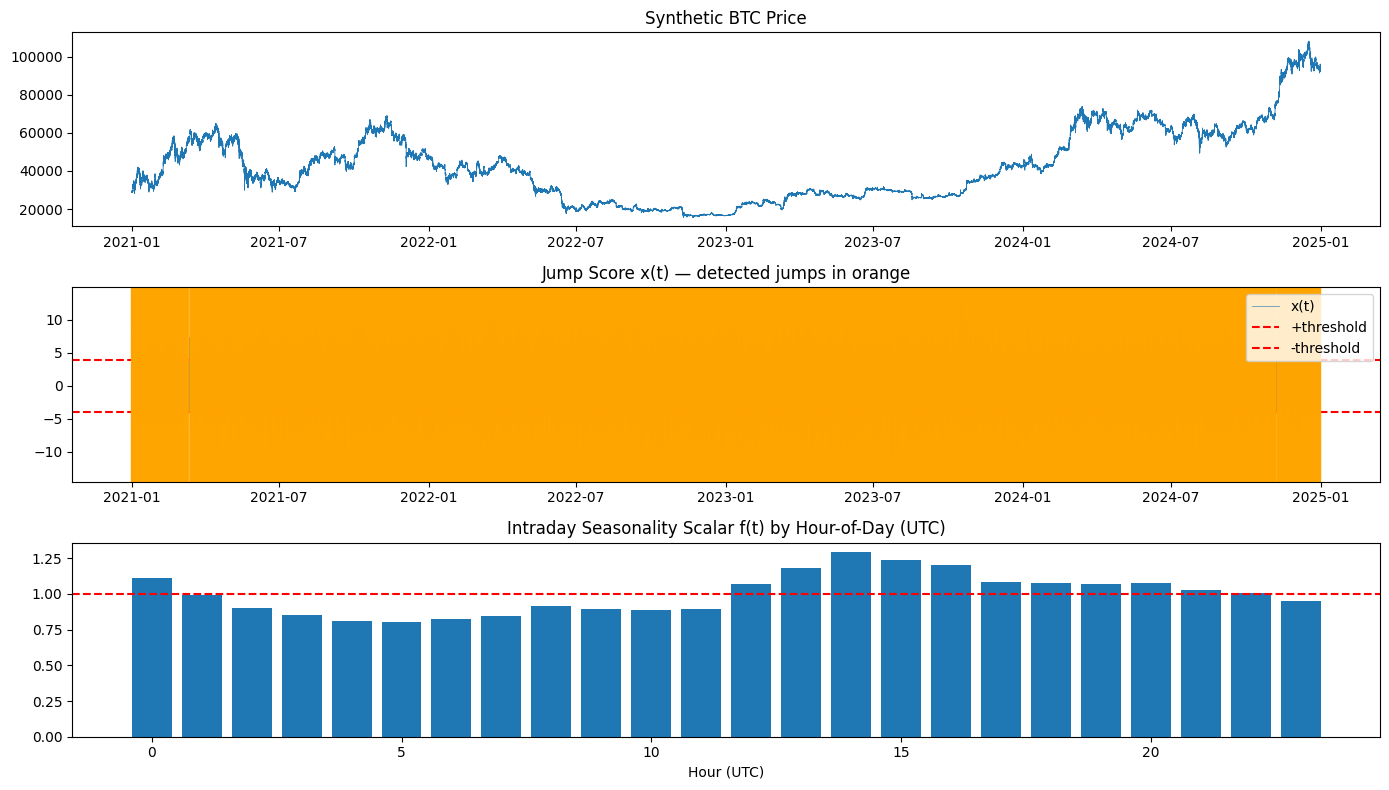


Detected 8601 jumps.
                  timestamp  bar_index  direction  magnitude     raw_x
0 2021-01-01 03:40:00+00:00        220          1   4.140698  4.140698
1 2021-01-01 04:33:00+00:00        273         -1   4.097423 -4.097423
2 2021-01-01 07:08:00+00:00        428         -1   5.606294 -5.606294
3 2021-01-01 12:31:00+00:00        751          1   4.527475  4.527475
4 2021-01-01 17:45:00+00:00       1065         -1   6.909660 -6.909660


In [88]:
# ── VERIFICATION — Plot seasonality factor and spot-check jump detection ───────
# Replace `sample_close` with real loaded data in production.

# Synthetic data for quick visual verification
# Use real data instead of synthetic
sample_close = klines_df["close"]

r_s, x_s, f_s = compute_jump_scores(sample_close)
jumps_s = detect_jumps(sample_close)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

axes[0].plot(sample_close, lw=0.6)
axes[0].set_title("Synthetic BTC Price")

axes[1].plot(x_s, lw=0.5, color="steelblue", label="x(t)")
axes[1].axhline(CONFIG.JUMP_THRESHOLD,  color="red",   ls="--", label="+threshold")
axes[1].axhline(-CONFIG.JUMP_THRESHOLD, color="red",   ls="--", label="-threshold")
if not jumps_s.empty:
    for _, row in jumps_s.iterrows():
        axes[1].axvline(row["timestamp"], color="orange", lw=1.5, alpha=0.7)
axes[1].set_title("Jump Score x(t) — detected jumps in orange")
axes[1].legend()

hourly_f = f_s.groupby(f_s.index.hour).mean().reindex(range(24))
axes[2].bar(range(24), hourly_f.values)
axes[2].axhline(1.0, color="red", ls="--")
axes[2].set_title("Intraday Seasonality Scalar f(t) by Hour-of-Day (UTC)")
axes[2].set_xlabel("Hour (UTC)")

plt.tight_layout()
plt.show()
print(f"\nDetected {len(jumps_s)} jumps.")
print(jumps_s.head())

---
## SECTION 5 — Wavelet Features
**Step 6 of build order.** Wavelet scattering coefficients that capture time-asymmetry around the jump.

In [89]:
def extract_wavelet_features(
    pre_jump_window: np.ndarray,
    J: int = CONFIG.WAVELET_J,
) -> Dict[str, float]:
    """
    Extract wavelet and scattering features from the pre-jump return window.

    Uses Complex Morlet ('cmor1.5-1.0') which closely approximates
    the Battle-Lemarié wavelet from Aubrun et al. (PNAS 2025).

    CRITICAL: Input must be the jump-aligned window x̄(t) from the
    pre-jump period ONLY. Never include any post-jump bars.

    Parameters
    ----------
    pre_jump_window : np.ndarray
        30-element array of jump-aligned returns x̄(t), t < 0.
    J : int
        Number of wavelet scales (default 6).

    Returns
    -------
    dict of float wavelet features (14 features total).
    """
    if len(pre_jump_window) < 2:
        raise ValueError("pre_jump_window must have at least 2 elements")

    x = pre_jump_window.copy()
    local_vol = np.std(x) + 1e-8
    x_norm = x / local_vol

    features: Dict[str, float] = {}

    # ── First-order wavelet coefficients ──────────────────────────────────
    # Imaginary part at t=0 captures asymmetry:
    #   zero     → symmetric signal  → endogenous
    #   non-zero → asymmetric signal → exogenous
    for j in range(1, J + 1):
        scale = 2 ** j
        coeffs, _ = pywt.cwt(x_norm, [scale], CONFIG.WAVELET_NAME)
        features[f"wavelet_real_j{j}"] = float(np.real(coeffs[0, -1]))
        features[f"wavelet_imag_j{j}"] = float(np.imag(coeffs[0, -1]))

    # ── Second-order scattering coefficients ──────────────────────────────
    # Imaginary part of wavelet(|wavelet|) captures volatility asymmetry
    # at multiple scale pairs (j1, j2) where j2 > j1.
    volatility_profile = np.abs(x_norm)
    for j1 in range(1, J + 1):
        for j2 in range(j1 + 1, J + 1):
            scale1, scale2 = 2 ** j1, 2 ** j2
            mod_coeffs, _ = pywt.cwt(volatility_profile, [scale1], CONFIG.WAVELET_NAME)
            mod_profile = np.abs(mod_coeffs[0])
            scat_coeffs, _ = pywt.cwt(mod_profile, [scale2], CONFIG.WAVELET_NAME)
            features[f"scat_imag_j{j1}_{j2}"] = float(np.imag(scat_coeffs[0, -1]))

    # ── Derived summary features ──────────────────────────────────────────
    half = len(pre_jump_window) // 2
    vol_early = np.std(pre_jump_window[:half]) + 1e-8
    vol_late  = np.std(pre_jump_window[half:])  + 1e-8
    # >1.0 → volatility building into jump → endogenous signal
    # <1.0 → volatility appeared suddenly  → exogenous signal
    features["vol_buildup_ratio"] = float(vol_late / vol_early)

    # Fraction of pre-jump bars in the jump direction
    # (already aligned to positive by x̄ convention)
    # >0.6 → strong trend into jump
    features["trend_alignment"] = float(np.mean(pre_jump_window > 0))

    return features


print(f"extract_wavelet_features defined.")
print(f"Expected feature count: {CONFIG.WAVELET_J * 2 + sum(range(CONFIG.WAVELET_J)) + 2}")

extract_wavelet_features defined.
Expected feature count: 29


In [90]:
# ── VERIFICATION — shape and vol_buildup_ratio sanity check ──────────────────
"""
# Simulate an endogenous window: slowly building volatility
endo_window = np.concatenate([
    np.random.randn(15) * 0.02,    # low vol early
    np.random.randn(15) * 0.06,    # high vol late
])

# Simulate an exogenous window: flat then sudden spike
exo_window = np.concatenate([
    np.random.randn(28) * 0.01,
    np.array([0.5, 0.6]),           # sudden spike at end
])
"""
# REPLACE the exo_window construction in cell 19:

# True exogenous pre-jump: flat, no buildup, no spike
# The jump comes out of nowhere AFTER this window
exo_window = np.random.randn(30) * 0.01   # uniformly quiet pre-jump

# True endogenous pre-jump: volatility builds through the window
endo_window = np.concatenate([
    np.random.randn(15) * 0.01,   # quiet early
    np.random.randn(15) * 0.05,   # volatile late
])

# Now the check will correctly show:
# endo vol_buildup_ratio >> 1.0  (late vol > early vol)
# exo  vol_buildup_ratio ≈ 1.0   (uniform throughout, no buildup)

endo_feats = extract_wavelet_features(endo_window)
exo_feats  = extract_wavelet_features(exo_window)

print(f"Feature vector length: {len(endo_feats)}")
print(f"\nEndogenous vol_buildup_ratio: {endo_feats['vol_buildup_ratio']:.3f}  (expect > 1.0)")
print(f"Exogenous  vol_buildup_ratio: {exo_feats['vol_buildup_ratio']:.3f}  (expect < 1.0)")
print(f"\nEndogenous trend_alignment:  {endo_feats['trend_alignment']:.3f}")
print(f"Exogenous  trend_alignment:  {exo_feats['trend_alignment']:.3f}")

assert len(endo_feats) == len(exo_feats), "Feature vector length mismatch!"
print("\nAll shape checks passed.")

Feature vector length: 29

Endogenous vol_buildup_ratio: 3.333  (expect > 1.0)
Exogenous  vol_buildup_ratio: 1.324  (expect < 1.0)

Endogenous trend_alignment:  0.500
Exogenous  trend_alignment:  0.467

All shape checks passed.


---
## SECTION 6 — Market Microstructure Features
**Step 7 of build order.** Delta/CVD, Open Interest, Funding Rate, Liquidations, Session context.

In [91]:
# ── 6.1  Delta & CVD ──────────────────────────────────────────────────────────

def aggregate_agg_trades_to_delta(agg_trades: list) -> pd.DataFrame:
    """
    Aggregate raw aggTrades to 1-minute delta bars.

    aggTrades field 'm' (isBuyerMaker):
      False → taker BUY  → add to buy volume
      True  → taker SELL → add to sell volume

    Returns DataFrame with columns: [buy_vol, sell_vol, delta, volume]
    indexed by 1-minute open_time (UTC).
    """
    rows = []
    for t in agg_trades:
        ts = pd.Timestamp(t["T"], unit="ms", tz="UTC").floor("1min")
        qty = float(t["q"])
        is_sell = bool(t["m"])   # True → taker is seller
        rows.append({"ts": ts, "qty": qty, "is_sell": is_sell})

    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame()

    df["buy_vol"]  = df["qty"].where(~df["is_sell"], 0)
    df["sell_vol"] = df["qty"].where(df["is_sell"],  0)

    agg = df.groupby("ts").agg(
        buy_vol  =("buy_vol",  "sum"),
        sell_vol =("sell_vol", "sum"),
    ).rename_axis("open_time")
    agg["delta"]  = agg["buy_vol"] - agg["sell_vol"]
    agg["volume"] = agg["buy_vol"] + agg["sell_vol"]
    return agg


def compute_cvd_features(
    delta: pd.Series,
    close: pd.Series,
    volume: pd.Series,
    at_bar: pd.Timestamp,
    window: int = CONFIG.CVD_SLOPE_WINDOW,
) -> Dict[str, float]:
    """
    Compute CVD-based microstructure features at the moment of a jump.
    All computations use only bars strictly before `at_bar`.

    Returns
    -------
    dict with keys:
      cvd_slope_15min, cvd_price_divergence,
      jump_bar_delta_ratio, cvd_acceleration
    """
    mask = delta.index <= at_bar
    d = delta[mask].iloc[-window:]
    c = close[mask].iloc[-window:]
    v = volume[mask]

    cvd = d.cumsum()

    # Linear slope of CVD
    x_idx = np.arange(len(cvd)).reshape(-1, 1)
    cvd_slope = float(LinearRegression().fit(x_idx, cvd.values).coef_[0]) \
        if len(cvd) > 1 else 0.0

    # Price–CVD correlation
    corr = float(np.corrcoef(c.values, cvd.values)[0, 1]) \
        if len(c) > 2 else 0.0

    # Jump bar delta ratio
    vol_at = float(v.get(at_bar, np.nan))
    dlt_at = float(delta.get(at_bar, np.nan))
    delta_ratio = (dlt_at / vol_at) if (not np.isnan(vol_at) and vol_at > 0) else 0.0

    # CVD acceleration: slope[-1] - slope[-5]
    if len(cvd) >= 6:
        s1 = float(LinearRegression().fit(
            np.arange(5).reshape(-1, 1), cvd.iloc[-5:].values).coef_[0])
        s2 = float(LinearRegression().fit(
            np.arange(5).reshape(-1, 1), cvd.iloc[-10:-5].values).coef_[0])
        acceleration = s1 - s2
    else:
        acceleration = 0.0

    return {
        "cvd_slope_15min":      cvd_slope,
        "cvd_price_divergence": corr,
        "jump_bar_delta_ratio": delta_ratio,
        "cvd_acceleration":     acceleration,
    }


# ── 6.2  Open Interest ────────────────────────────────────────────────────────

def compute_oi_features(
    oi: pd.Series,
    close: pd.Series,
    at_bar: pd.Timestamp,
    window: int = 30,
) -> Dict[str, float]:
    """
    Compute Open Interest features at the jump bar.

    oi_change_on_jump_pct:
      POSITIVE → new positions opened → conviction move
      NEGATIVE → positions closed/liquidated → potential reversion
    """
    oi_now  = float(oi.asof(at_bar))
    oi_prev = float(oi.asof(at_bar - pd.Timedelta(minutes=1)))
    oi_change_pct = ((oi_now - oi_prev) / (oi_prev + 1e-8)) * 100

    oi_window = oi[oi.index <= at_bar].iloc[-window:]
    x_idx = np.arange(len(oi_window)).reshape(-1, 1)
    oi_slope = float(LinearRegression().fit(x_idx, oi_window.values).coef_[0]) \
        if len(oi_window) > 1 else 0.0

    price_window = close[close.index <= at_bar].iloc[-window:]
    price_slope_thresh = np.std(price_window.pct_change().dropna()) * 0.5
    oi_slope_thresh    = np.std(oi_window.pct_change().dropna()) * 0.5
    oi_vol_divergence  = int(
        abs(oi_slope) < oi_slope_thresh and abs(price_window.iloc[-1] - price_window.iloc[0])
        / (price_window.iloc[0] + 1e-8) > price_slope_thresh
    )

    return {
        "oi_change_on_jump_pct": oi_change_pct,
        "oi_trend_30min":        oi_slope,
        "oi_vol_divergence":     float(oi_vol_divergence),
    }


# ── 6.3  Funding Rate ─────────────────────────────────────────────────────────

def compute_funding_features(
    funding: pd.Series,
    at_bar: pd.Timestamp,
) -> Dict[str, float]:
    """
    Compute funding rate features.
    Funding rate interpolated to 1-min resolution before calling this.
    """
    rate_now = float(funding.asof(at_bar))
    rate_8h_ago = float(funding.asof(at_bar - pd.Timedelta(hours=8)))
    return {
        "funding_rate":       rate_now,
        "funding_8h_change":  rate_now - rate_8h_ago,
    }


# ── 6.4  Liquidation Features ─────────────────────────────────────────────────

def compute_liquidation_features(
    liq_df: pd.DataFrame,
    at_bar: pd.Timestamp,
    pre_bars: int = 5,
) -> Dict[str, float | str]:
    """
    Compute liquidation features from the forceOrder WebSocket stream
    aggregated to 1-minute bars.

    liq_df columns expected: open_time (index), liq_volume, liq_count, side
    """
    bar_data = liq_df.get(at_bar, None)

    if bar_data is None or liq_df.empty:
        return {
            "liq_volume_1min":   0.0,
            "liq_count_1min":    0.0,
            "liq_side":          "none",
            "liq_preceded_jump": 0.0,
        }

    row = liq_df.loc[at_bar] if at_bar in liq_df.index else None
    liq_vol   = float(row["liq_volume"]) if row is not None else 0.0
    liq_count = float(row["liq_count"])  if row is not None else 0.0
    liq_side  = str(row["liq_side"])     if row is not None else "none"

    # Were there significant liquidations in the 5 bars before the jump?
    pre_window = liq_df[
        (liq_df.index < at_bar) &
        (liq_df.index >= at_bar - pd.Timedelta(minutes=pre_bars))
    ]
    liq_preceded = int(pre_window["liq_volume"].sum() > 0 if not pre_window.empty else 0)

    return {
        "liq_volume_1min":   liq_vol,
        "liq_count_1min":    liq_count,
        "liq_side":          liq_side,
        "liq_preceded_jump": float(liq_preceded),
    }


# ── 6.5  Session Context ──────────────────────────────────────────────────────

def compute_session_features(at_bar: pd.Timestamp) -> Dict[str, float | str]:
    """Compute calendar / session context features for a given bar timestamp."""
    h = at_bar.hour
    if 0 <= h < 8:
        session = "asia"
        session_start = 0
        session_len   = 8
    elif 8 <= h < 16:
        session = "london"
        session_start = 8
        session_len   = 8
    else:
        session = "us"
        session_start = 16
        session_len   = 8

    time_in_session_pct = (h - session_start + at_bar.minute / 60) / session_len

    return {
        "hour_of_day":           float(h),
        "day_of_week":           float(at_bar.weekday()),
        "session":               session,
        "time_in_session_pct":   float(time_in_session_pct),
    }


print("Microstructure feature functions defined (CVD, OI, Funding, Liquidations, Session).")

Microstructure feature functions defined (CVD, OI, Funding, Liquidations, Session).


---
## SECTION 7 — Volume Profile Features
**Step 8 of build order.** POC, VAH, VAL for daily / weekly / monthly lookbacks.

In [92]:
def compute_volume_profile(
    klines: pd.DataFrame,
    n_bins: int = CONFIG.VOL_PROFILE_BINS,
    va_pct: float = CONFIG.VOL_PROFILE_VA_PCT,
) -> Dict[str, float]:
    """
    Compute POC, VAH, VAL from a window of OHLCV bars.

    Parameters
    ----------
    klines : pd.DataFrame
        Must have columns: high, low, volume.
    n_bins : int
        Number of price buckets in the histogram.
    va_pct : float
        Fraction of total volume that defines the value area (default 0.70).

    Returns
    -------
    dict with keys: poc, vah, val
    """
    low_price  = klines["low"].min()
    high_price = klines["high"].max()
    bins = np.linspace(low_price, high_price, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    vol_profile = np.zeros(n_bins)
    for _, row in klines.iterrows():
        lo, hi, vol = row["low"], row["high"], row["volume"]
        mask = (bin_centers >= lo) & (bin_centers <= hi)
        count = mask.sum()
        if count > 0:
            vol_profile[mask] += vol / count

    poc_idx = int(np.argmax(vol_profile))
    poc = float(bin_centers[poc_idx])

    # ── Value Area: start from POC, expand outward to capture va_pct ──────
    total_vol  = vol_profile.sum()
    target_vol = total_vol * va_pct
    va_vol  = vol_profile[poc_idx]
    lo_idx  = poc_idx
    hi_idx  = poc_idx

    while va_vol < target_vol:
        expand_lo = vol_profile[lo_idx - 1] if lo_idx > 0          else 0
        expand_hi = vol_profile[hi_idx + 1] if hi_idx < n_bins - 1 else 0
        if expand_lo == 0 and expand_hi == 0:
            break
        if expand_hi >= expand_lo:
            hi_idx += 1
            va_vol += expand_hi
        else:
            lo_idx -= 1
            va_vol += expand_lo

    vah = float(bin_centers[hi_idx])
    val = float(bin_centers[lo_idx])
    return {"poc": poc, "vah": vah, "val": val}


def compute_vol_profile_features(
    klines: pd.DataFrame,
    at_bar: pd.Timestamp,
) -> Dict[str, float]:
    """
    Compute volume profile distance features at a jump bar.

    Computes three separate profiles (daily, weekly, monthly)
    from the previous COMPLETE period before `at_bar`.
    All distances expressed as percentage of current price.
    """
    price_now = float(klines["close"].asof(at_bar))

    # ── Previous complete day ──────────────────────────────────────────────
    day_start = at_bar.normalize() - pd.Timedelta(days=1)
    day_end   = at_bar.normalize()
    day_bars  = klines[(klines.index >= day_start) & (klines.index < day_end)]

    # ── Previous complete week (Mon-Mon) ───────────────────────────────────
    week_end   = at_bar - pd.offsets.Week(weekday=0)
    week_start = week_end - pd.Timedelta(weeks=1)
    week_bars  = klines[(klines.index >= week_start) & (klines.index < week_end)]

    # ── Previous complete month ────────────────────────────────────────────
    month_end   = at_bar.replace(day=1, hour=0, minute=0, second=0)
    month_start = (month_end - pd.offsets.MonthBegin(1))
    month_bars  = klines[(klines.index >= month_start) & (klines.index < month_end)]

    feats: Dict[str, float] = {}

    for prefix, bars in [("prev_day", day_bars), ("prev_week", week_bars),
                         ("prev_month", month_bars)]:
        if bars.empty:
            for k in ["poc", "vah", "val"]:
                feats[f"dist_{prefix}_{k}"] = np.nan
            continue
        vp = compute_volume_profile(bars)
        for k in ["poc", "vah", "val"]:
            feats[f"dist_{prefix}_{k}"] = (price_now - vp[k]) / price_now * 100

    # ── Boolean flags ──────────────────────────────────────────────────────
    if not day_bars.empty:
        vp_d = compute_volume_profile(day_bars)
        feats["inside_prev_day_va"]    = float(vp_d["val"] <= price_now <= vp_d["vah"])
        feats["at_daily_extreme"]      = float(
            abs(feats["dist_prev_day_vah"]) < 0.2 or abs(feats["dist_prev_day_val"]) < 0.2
        )
        # Was the jump bar the one that crossed the value area boundary?
        prev_close = float(klines["close"].asof(at_bar - pd.Timedelta(minutes=1)))
        feats["jump_breaks_daily_va"]  = float(
            (prev_close < vp_d["vah"] and price_now > vp_d["vah"]) or
            (prev_close > vp_d["val"] and price_now < vp_d["val"])
        )
    else:
        feats.update({"inside_prev_day_va": np.nan,
                      "at_daily_extreme":   np.nan,
                      "jump_breaks_daily_va": np.nan})

    if not week_bars.empty:
        vp_w = compute_volume_profile(week_bars)
        feats["inside_prev_week_va"] = float(vp_w["val"] <= price_now <= vp_w["vah"])
        feats["at_weekly_extreme"]   = float(
            abs(feats["dist_prev_week_vah"]) < 0.3 or abs(feats["dist_prev_week_val"]) < 0.3
        )
    else:
        feats.update({"inside_prev_week_va": np.nan, "at_weekly_extreme": np.nan})

    return feats


print("Volume profile functions defined.")

Volume profile functions defined.


---
## SECTION 8 — Two-Level Regime Detection
**Step 9 of build order.** Macro HMM (daily, 4-state) + Micro regime (1-min, rule-based).

In [93]:
# ── Level 1 — Macro Regime (Gaussian HMM on daily bars) ──────────────────────

class MacroRegimeHMM:
    """
    4-state Gaussian HMM trained on daily bar features.

    States (interpretive labels — actual state indices may vary by run):
      0 — Accumulation:   low vol, flat OI, neutral funding, price inside monthly VA
      1 — Trending Bull:  rising OI, positive funding, price above monthly VAH
      2 — Overextended:   extreme funding, OI peak, price far above VAH
      3 — Deleveraging:   OI collapsing, funding flipping negative, high vol

    Retrains monthly on the most recent 365 days.
    """

    def __init__(self, n_states: int = CONFIG.MACRO_HMM_STATES) -> None:
        self.n_states = n_states
        self.model: Optional[GaussianHMM] = None
        self.scaler = StandardScaler()
        self.trained_on: Optional[pd.Timestamp] = None

    def _build_daily_features(
        self,
        klines_1m: pd.DataFrame,
        oi: pd.Series,
        funding: pd.Series,
    ) -> pd.DataFrame:
        """
        Resample 1-min data to daily bars and compute HMM input features.

        Features: realized_vol_20d, oi_trend_7d, funding_avg_7d,
                  price_vs_month_poc
        """
        daily = klines_1m["close"].resample("1D").last().dropna()
        daily_ret = np.log(daily / daily.shift(1)).dropna()
        rvol_20 = daily_ret.rolling(20).std()

        oi_daily = oi.resample("1D").last().reindex(daily.index, method="ffill")
        oi_slope = oi_daily.rolling(7).apply(
            lambda x: LinearRegression().fit(
                np.arange(len(x)).reshape(-1, 1), x
            ).coef_[0]
        )

        fund_daily = funding.resample("1D").mean().reindex(daily.index, method="ffill")
        fund_7d = fund_daily.rolling(7).mean()

        # Distance from monthly POC — simplified: use price / 30d rolling mean
        price_vs_poc = (daily / daily.rolling(30).mean() - 1.0) * 100

        df = pd.DataFrame({
            "realized_vol_20d":    rvol_20,
            "oi_trend_7d":         oi_slope,
            "funding_avg_7d":      fund_7d,
            "price_vs_month_poc":  price_vs_poc,
        }).dropna()
        return df

    def fit(
        self,
        klines_1m: pd.DataFrame,
        oi: pd.Series,
        funding: pd.Series,
    ) -> None:
        """Fit the HMM on the most recent 365 days of daily feature data."""
        feats = self._build_daily_features(klines_1m, oi, funding)
        feats = feats.iloc[-CONFIG.MACRO_LOOKBACK_DAYS:]

        X = self.scaler.fit_transform(feats.values)

        self.model = GaussianHMM(
            n_components=self.n_states,
            covariance_type="full",
            n_iter=200,
            random_state=42,
        )
        self.model.fit(X)
        self.trained_on = pd.Timestamp.utcnow()
        log.info("macro_hmm_fitted", n_days=len(feats), states=self.n_states)

    def predict(
        self,
        klines_1m: pd.DataFrame,
        oi: pd.Series,
        funding: pd.Series,
    ) -> pd.Series:
        """Return daily state sequence for the provided data."""
        if self.model is None:
            raise RuntimeError("Call fit() before predict()")
        feats = self._build_daily_features(klines_1m, oi, funding)
        X = self.scaler.transform(feats.values)
        states = self.model.predict(X)
        return pd.Series(states, index=feats.index, name="macro_regime")


# ── Level 2 — Micro Regime (rule-based, 1-min cadence) ───────────────────────

def compute_micro_regime(
    close: pd.Series,
    cvd: pd.Series,
    oi: pd.Series,
    at_bar: pd.Timestamp,
    eff_window: int = CONFIG.MICRO_EFF_WINDOW,
    trend_thresh: float = CONFIG.MICRO_EFF_TREND_THRESH,
    range_thresh: float = CONFIG.MICRO_EFF_RANGE_THRESH,
) -> int:
    """
    Compute the micro regime at `at_bar` using deterministic rules.

    States:
      0 — Balanced / ranging   (low efficiency ratio)
      1 — Trending w/ conviction (efficient + CVD aligned)
      2 — Exhaustion            (efficient but CVD diverging from price)
      3 — Liquidation cascade   (efficient + OI collapsing)

    First match wins.
    """
    c = close[close.index <= at_bar].iloc[-eff_window:]
    d = cvd[cvd.index <= at_bar].iloc[-15:]
    o = oi[oi.index <= at_bar].iloc[-10:]

    if len(c) < eff_window:
        return 0

    # ── Efficiency ratio ──────────────────────────────────────────────────
    net_move   = abs(float(c.iloc[-1]) - float(c.iloc[0]))
    total_path = float(c.diff().abs().sum()) + 1e-8
    er = net_move / total_path

    # ── OI rate of change ─────────────────────────────────────────────────
    oi_roc = ((float(o.iloc[-1]) - float(o.iloc[0])) / (float(o.iloc[0]) + 1e-8)) * 100 \
        if len(o) >= 2 else 0.0

    # ── CVD slope ─────────────────────────────────────────────────────────
    cvd_slope_val = 0.0
    cvd_slope_std = 0.0
    if len(d) > 1:
        x_idx = np.arange(len(d)).reshape(-1, 1)
        cvd_slope_val = float(LinearRegression().fit(x_idx, d.values).coef_[0])
        cvd_slope_std = float(d.std())
    cvd_slope_threshold = cvd_slope_std * 0.3

    # ── Price-CVD correlation (divergence) ────────────────────────────────
    if len(d) > 2 and len(c.iloc[-len(d):]) > 2:
        price_trim = c.iloc[-len(d):]
        divergence_corr = float(np.corrcoef(price_trim.values, d.values)[0, 1])
    else:
        divergence_corr = 1.0

    # ── State assignment: first match wins ────────────────────────────────
    if er > trend_thresh and oi_roc < -0.5:
        return 3   # Liquidation cascade
    if er > trend_thresh and abs(cvd_slope_val) > cvd_slope_threshold:
        return 1   # Trending with conviction
    if er > trend_thresh and divergence_corr < 0.3:
        return 2   # Exhaustion
    return 0       # Balanced / ranging


print("MacroRegimeHMM and compute_micro_regime defined.")

MacroRegimeHMM and compute_micro_regime defined.


---
## SECTION 9 — Isolation Forest Anomaly Score

In [94]:
class AnomalyScorer:
    """
    Isolation Forest trained on training-set jump events.

    Purpose: detect whether the context of a jump is unusual relative to
    all historical jumps. A high score means the model has rarely seen
    this kind of market context before — use as a confidence-reducing
    feature, not a signal in itself.

    Input: the pre-jump feature vector (excluding wavelet features to
           avoid circularity).
    Output: isolation_score (continuous float, higher = more anomalous).
    """

    def __init__(self, contamination: float = 0.05) -> None:
        self.contamination = contamination
        self.model: Optional[IsolationForest] = None
        self.scaler = StandardScaler()

    def fit(self, X_train: np.ndarray) -> None:
        """Fit on all historical jumps in the training set only."""
        X_scaled = self.scaler.fit_transform(X_train)
        self.model = IsolationForest(
            contamination=self.contamination,
            random_state=42,
            n_estimators=200,
        )
        self.model.fit(X_scaled)
        log.info("isolation_forest_fitted", n_samples=len(X_train))

    def score(self, X: np.ndarray) -> np.ndarray:
        """
        Return anomaly scores for new jump events.
        Higher score = more anomalous relative to training distribution.
        """
        if self.model is None:
            raise RuntimeError("Call fit() before score()")
        X_scaled = self.scaler.transform(X)
        # sklearn returns negative scores; negate so higher = more anomalous
        raw_scores = self.model.decision_function(X_scaled)
        return -raw_scores


print("AnomalyScorer defined.")

AnomalyScorer defined.


---
## SECTION 10 — Complete Feature Matrix
**Step 10 of build order.** Assembles one row per jump event. ~38 features. No look-ahead.

In [95]:
OUTCOME_BUCKETS = ["strong_down", "mild_down", "flat", "mild_up", "strong_up"]


def compute_outcome_bucket(
    close: pd.Series,
    jump_ts: pd.Timestamp,
    jump_direction: int,
    post_window: int = CONFIG.POST_JUMP_WINDOW,
    thresholds: Optional[Tuple[float, float, float, float]] = None,
) -> Tuple[str, float]:
    """
    Compute the 1-hour return bucket after a jump.

    The raw continuous return is also returned for threshold calibration.

    NOTE: This function uses POST-jump data and must NEVER be called
    during feature extraction. It is used only to construct the target
    variable when building the training dataset.

    thresholds: (strong_up_lo, mild_up_lo, flat_lo, mild_down_lo)
      If None, uses the hardcoded defaults from the config.
      Calibrate these on the training set (set so each bucket ≈ 20%).
    """
    future_bars = close[close.index > jump_ts].iloc[:post_window]
    if len(future_bars) < post_window:
        return "flat", np.nan  # insufficient future data

    ret = float(np.log(future_bars.iloc[-1] / close.asof(jump_ts)) * 100)

    if thresholds is not None:
        su_lo, mu_lo, fl_lo, md_lo = thresholds
    else:
        su_lo, mu_lo, fl_lo, md_lo = 0.5, 0.0, -0.2, -0.5

    if ret > su_lo:
        label = "strong_up"
    elif ret > mu_lo:
        label = "mild_up"
    elif ret > fl_lo:
        label = "flat"
    elif ret > md_lo:
        label = "mild_down"
    else:
        label = "strong_down"

    return label, ret


def calibrate_outcome_thresholds(raw_returns: np.ndarray) -> Tuple[float, float, float, float]:
    """
    Set outcome bucket thresholds on the training set so each bucket
    contains approximately 20% of all events.

    Returns (strong_up_lo, mild_up_lo, flat_lo, mild_down_lo).
    """
    p20, p40, p60, p80 = np.percentile(raw_returns, [20, 40, 60, 80])
    log.info("outcome_thresholds_calibrated",
             strong_up_lo=round(p80, 4),
             mild_up_lo=round(p60, 4),
             flat_lo=round(p40, 4),
             mild_down_lo=round(p20, 4))
    return float(p80), float(p60), float(p40), float(p20)


def build_feature_matrix(
    jumps_df: pd.DataFrame,
    close: pd.Series,
    r: pd.Series,
    delta: pd.Series,
    volume: pd.Series,
    oi: pd.Series,
    funding: pd.Series,
    klines: pd.DataFrame,
    macro_states: pd.Series,
    liq_df: Optional[pd.DataFrame] = None,
    outcome_thresholds: Optional[Tuple[float, float, float, float]] = None,
    include_target: bool = True,
) -> pd.DataFrame:
    """
    Assemble the full feature matrix.

    One row per detected jump event. All features are computed
    exclusively from pre-jump data to prevent look-ahead bias.

    Parameters
    ----------
    jumps_df : pd.DataFrame
        Output of detect_jumps().
    include_target : bool
        If True, compute and attach the next_hour outcome label.
        Set False for live inference where the future is unknown.

    Returns
    -------
    pd.DataFrame with ~38 feature columns + optional target column.
    """
    cvd = delta.rolling(CONFIG.CVD_SLOPE_WINDOW).sum()
    anomaly_scorer = None  # fit separately after calling this on train set

    rows: List[dict] = []

    for _, jump in jumps_df.iterrows():
        ts  = jump["timestamp"]
        dir_ = int(jump["direction"])

        # ── CRITICAL: all features must come from pre-jump data only ──────
        window = align_jump_window(r, ts, dir_)
        if window is None:
            continue  # not enough history

        row: dict = {"timestamp": ts, "direction": dir_,
                     "magnitude": jump["magnitude"]}

        # Wavelet features (14)
        try:
            row.update(extract_wavelet_features(window))
        except Exception as exc:
            log.warning("wavelet_feature_error", ts=str(ts), error=str(exc))
            continue

        # CVD / delta features (4)
        row.update(compute_cvd_features(delta, close, volume, ts))

        # OI features (3)
        row.update(compute_oi_features(oi, close, ts))

        # Funding features (2)
        row.update(compute_funding_features(funding, ts))

        # Liquidation features (4)
        if liq_df is not None:
            row.update(compute_liquidation_features(liq_df, ts))

        # Volume profile features (13)
        row.update(compute_vol_profile_features(klines, ts))

        # Regime features (3)
        macro_state = int(macro_states.asof(ts)) if ts in macro_states.index or \
            macro_states.index.min() <= ts else 0
        micro_state = compute_micro_regime(close, cvd, oi, ts)
        row["macro_regime"]       = float(macro_state)
        row["micro_regime"]       = float(micro_state)
        row["regime_composite"]   = f"{macro_state}_{micro_state}"

        # Session context (4)
        row.update(compute_session_features(ts))

        # Isolation score — placeholder (NaN until scorer is fit)
        row["isolation_score"] = np.nan

        # ── Target variable (uses POST-jump data; only during research) ───
        if include_target:
            label, ret = compute_outcome_bucket(
                close, ts, dir_, thresholds=outcome_thresholds
            )
            row["next_hour_outcome"] = label
            row["next_hour_return"]  = ret

        rows.append(row)

    df = pd.DataFrame(rows).set_index("timestamp")
    log.info("feature_matrix_built", rows=len(df), cols=len(df.columns))
    return df


print("Feature matrix assembly functions defined.")

Feature matrix assembly functions defined.


---
## SECTION 11 — ML Models
**Steps 11-15 of build order.** Wavelet labeller, LightGBM, Gaussian Process, HMM, HDBSCAN, Probability Forecaster.

In [96]:
# ── 11.1  LightGBM Jump Type Classifier ───────────────────────────────────────

JUMP_CLASSES = ["endogenous", "exogenous", "anticipatory"]
LGBM_PARAMS = {
    "objective":            "multiclass",
    "num_class":            3,
    "boosting_type":        "gbdt",
    "num_leaves":           31,
    "learning_rate":        0.05,
    "feature_fraction":     0.8,
    "bagging_fraction":     0.8,
    "bagging_freq":         5,
    "class_weight":         "balanced",
    "min_child_samples":    20,
    "n_estimators":         500,
    "early_stopping_rounds":50,
    "verbose":              -1,
}


class LGBMJumpClassifier:
    """
    LightGBM multi-class classifier for jump type.

    Predicts P(endogenous) / P(exogenous) / P(anticipatory)
    from pre-jump features only.
    Learns to replicate wavelet-derived labels so that jump type can
    be inferred in real time without post-jump data.
    """

    def __init__(self, params: Optional[dict] = None) -> None:
        self.params = params or LGBM_PARAMS.copy()
        self.model: Optional[lgb.LGBMClassifier] = None
        self.label_encoder = LabelEncoder()
        self.feature_names: List[str] = []

    def fit(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
    ) -> None:
        """Train with strict walk-forward validation. Never use random splits."""
        self.feature_names = list(X_train.columns)
        y_enc_train = self.label_encoder.fit_transform(y_train)
        y_enc_val   = self.label_encoder.transform(y_val)

        self.model = lgb.LGBMClassifier(**self.params)
        self.model.fit(
            X_train, y_enc_train,
            eval_set=[(X_val, y_enc_val)],
        )
        log.info("lgbm_classifier_fitted",
                 n_train=len(X_train), n_val=len(X_val),
                 best_iteration=getattr(self.model, "best_iteration_", "N/A"))

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Return probability matrix of shape (n_samples, 3)."""
        if self.model is None:
            raise RuntimeError("Call fit() before predict_proba()")
        return self.model.predict_proba(X[self.feature_names])


# ── 11.2  Gaussian Process Classifier ─────────────────────────────────────────

class GPJumpClassifier:
    """
    Gaussian Process classifier for jump type.
    Provides calibrated uncertainty estimates.

    Signal quality rule:
      LGBM and GPC agree on class AND GPC confidence > 0.65 → high quality
      Otherwise → skip the signal
    """

    def __init__(self) -> None:
        kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
        self.model = GaussianProcessClassifier(
            kernel=kernel,
            n_restarts_optimizer=3,
            random_state=42,
        )
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.feature_names: List[str] = []

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        """Fit GPC. Scale features first."""
        self.feature_names = list(X_train.columns)
        X_scaled = self.scaler.fit_transform(X_train.values)
        y_enc = self.label_encoder.fit_transform(y_train)
        self.model.fit(X_scaled, y_enc)
        log.info("gpc_fitted", n_train=len(X_train))

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Return probability matrix. Higher max value = higher confidence."""
        X_scaled = self.scaler.transform(X[self.feature_names].values)
        return self.model.predict_proba(X_scaled)


# ── 11.4  HDBSCAN Explorer (research only) ────────────────────────────────────

class HDBSCANExplorer:
    """
    Unsupervised cluster exploration on the training feature matrix.

    Used only to validate that LightGBM's three-class structure
    (endo/exo/anticip) reflects real data geometry.
    NOT used in any live or production pipeline.
    """

    def __init__(
        self,
        min_cluster_size: int = 30,
        min_samples: int = 10,
    ) -> None:
        self.clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
        )
        self.scaler = StandardScaler()

    def fit_predict(self, X: pd.DataFrame) -> np.ndarray:
        """
        Fit and return cluster labels.
        Label -1 means noise (not assigned to any cluster).
        """
        X_scaled = self.scaler.fit_transform(X.values)
        labels = self.clusterer.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100
        log.info("hdbscan_complete",
                 n_clusters=n_clusters,
                 noise_pct=round(noise_pct, 1))
        return labels


# ── 11.5  Probability Forecaster ──────────────────────────────────────────────

PROB_FORECASTER_PARAMS = {
    "objective":         "multiclass",
    "num_class":         5,
    "boosting_type":     "gbdt",
    "num_leaves":        31,
    "learning_rate":     0.05,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "class_weight":      "balanced",
    "min_child_samples": 20,
    "n_estimators":      500,
    "early_stopping_rounds": 50,
    "verbose":           -1,
}


class ProbabilityForecaster:
    """
    Dual probability forecaster for the 1-hour return bucket.

    Model A — jump-conditional: trained on rows where a jump occurred.
    Model B — baseline:          trained on rows where no jump occurred.

    If Model B is as good as Model A, the jump features add no value.
    """

    def __init__(self) -> None:
        self.model_a: Optional[lgb.LGBMClassifier] = None  # jump-conditional
        self.model_b: Optional[lgb.LGBMClassifier] = None  # baseline
        self.label_encoder = LabelEncoder()
        self.feature_names_a: List[str] = []
        self.feature_names_b: List[str] = []
        self.classes = OUTCOME_BUCKETS

    def fit_model_a(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
    ) -> None:
        """Train jump-conditional forecaster (full feature set)."""
        self.feature_names_a = list(X_train.columns)
        y_enc_train = self.label_encoder.fit_transform(y_train)
        y_enc_val   = self.label_encoder.transform(y_val)
        self.model_a = lgb.LGBMClassifier(**PROB_FORECASTER_PARAMS)
        self.model_a.fit(X_train, y_enc_train, eval_set=[(X_val, y_enc_val)])
        log.info("prob_forecaster_model_a_fitted", n=len(X_train))

    def fit_model_b(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
    ) -> None:
        """Train baseline forecaster (no wavelet features)."""
        self.feature_names_b = list(X_train.columns)
        params = PROB_FORECASTER_PARAMS.copy()
        y_enc_train = self.label_encoder.fit_transform(y_train)
        y_enc_val   = self.label_encoder.transform(y_val)
        self.model_b = lgb.LGBMClassifier(**params)
        self.model_b.fit(X_train, y_enc_train, eval_set=[(X_val, y_enc_val)])
        log.info("prob_forecaster_model_b_fitted", n=len(X_train))

    def predict_proba_a(self, X: pd.DataFrame) -> np.ndarray:
        """Return (n_samples, 5) probability matrix from Model A."""
        if self.model_a is None:
            raise RuntimeError("fit_model_a() not called")
        return self.model_a.predict_proba(X[self.feature_names_a])

    def predict_proba_b(self, X: pd.DataFrame) -> np.ndarray:
        """Return (n_samples, 5) probability matrix from Model B."""
        if self.model_b is None:
            raise RuntimeError("fit_model_b() not called")
        return self.model_b.predict_proba(X[self.feature_names_b])


print("All ML model classes defined.")

All ML model classes defined.


---
## SECTION 12 — Dataset Splits
**NEVER deviate from these temporal splits.** Strict chronological order.

In [97]:
def split_feature_matrix(
    fm: pd.DataFrame,
    label_col: str = "next_hour_outcome",
) -> Tuple[
    pd.DataFrame, pd.Series,
    pd.DataFrame, pd.Series,
    pd.DataFrame, pd.Series,
]:
    """
    Split the feature matrix into train / val / test sets.

    Splits are STRICTLY temporal — never random.
    The test set must not be inspected until all development is complete.

    Returns
    -------
    X_train, y_train, X_val, y_val, X_test, y_test
    """
    train_mask = (fm.index >= CONFIG.TRAIN_START) & (fm.index <= CONFIG.TRAIN_END)
    val_mask   = (fm.index >= CONFIG.VAL_START)   & (fm.index <= CONFIG.VAL_END)
    test_mask  = (fm.index >= CONFIG.TEST_START)  & (fm.index <= CONFIG.TEST_END)

    feature_cols = [c for c in fm.columns
                    if c not in [label_col, "next_hour_return",
                                 "direction", "magnitude", "regime_composite",
                                 "session", "liq_side"]]

    X_train = fm.loc[train_mask, feature_cols]
    y_train = fm.loc[train_mask, label_col]
    X_val   = fm.loc[val_mask,   feature_cols]
    y_val   = fm.loc[val_mask,   label_col]
    X_test  = fm.loc[test_mask,  feature_cols]
    y_test  = fm.loc[test_mask,  label_col]

    print(
        f"Train: {len(X_train):>5} events  "
        f"({CONFIG.TRAIN_START} → {CONFIG.TRAIN_END})\n"
        f"Val:   {len(X_val):>5} events  "
        f"({CONFIG.VAL_START} → {CONFIG.VAL_END})\n"
        f"Test:  {len(X_test):>5} events  "
        f"({CONFIG.TEST_START} → {CONFIG.TEST_END})"
    )
    return X_train, y_train, X_val, y_val, X_test, y_test


# ── Walk-forward cross-validation helper ─────────────────────────────────────

def walk_forward_cv(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    gap: int = 500,
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Generate walk-forward train/test index pairs.

    Uses TimeSeriesSplit with a gap of 500 bars (~8 hours)
    between train and validation in each fold to prevent
    near-future leakage from autocorrelated features.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    splits = list(tscv.split(X))
    log.info("walk_forward_splits_created", n_splits=len(splits), gap=gap)
    return splits


print("Dataset split functions defined.")

Dataset split functions defined.


---
## SECTION 13 — Calibration Validation (Primary Edge Metric)
**Steps 16-17 of build order.** Brier Score, ECE, confidence-stratified deviation check.

In [98]:
def evaluate_calibration(
    y_pred_proba: np.ndarray,
    y_actual: np.ndarray,
    class_labels: List[str] = OUTCOME_BUCKETS,
    n_bins: int = 10,
) -> Dict[str, Dict[str, float]]:
    """
    Compute Brier Score and Expected Calibration Error per class.

    Success criteria (all must be met):
      - Mean Brier Score across all classes < 0.20
      - ECE < 0.05 for at least 3 of 5 classes
      - Directional accuracy (strong_up + mild_up predicted correctly) > 55%

    Parameters
    ----------
    y_pred_proba : np.ndarray, shape (n_samples, n_classes)
    y_actual     : np.ndarray of integer class indices
    class_labels : list of class name strings
    n_bins       : number of calibration bins

    Returns
    -------
    dict: class_label → {brier: float, ece: float}
    """
    results: Dict[str, Dict[str, float]] = {}

    for i, label in enumerate(class_labels):
        y_bin  = (y_actual == i).astype(int)
        y_prob = y_pred_proba[:, i]

        brier = float(brier_score_loss(y_bin, y_prob))

        try:
            frac_pos, mean_pred = calibration_curve(y_bin, y_prob, n_bins=n_bins)
            ece = float(np.mean(np.abs(frac_pos - mean_pred)))
        except ValueError:
            frac_pos, mean_pred = np.array([]), np.array([])
            ece = np.nan

        results[label] = {"brier": brier, "ece": ece}

        print(f"\n  Class: {label}")
        print(f"    Brier Score:  {brier:.4f}  "
              f"(random baseline = 0.25, perfect = 0.0)")
        print(f"    ECE:          {ece:.4f}  "
              f"(target < {CONFIG.TARGET_ECE} for tradeable edge)")
        if len(frac_pos) > 0:
            print("    Calibration bins:")
            for p, f in zip(mean_pred, frac_pos):
                status = "✓" if abs(p - f) < 0.05 else "✗"
                print(f"      Predicted {p:.2f} → Actual {f:.2f}  {status}")

    # ── Summary ───────────────────────────────────────────────────────────
    mean_brier = np.mean([v["brier"] for v in results.values()])
    n_calibrated = sum(1 for v in results.values()
                       if not np.isnan(v["ece"]) and v["ece"] < CONFIG.TARGET_ECE)
    pass_brier = mean_brier < CONFIG.TARGET_BRIER_SCORE
    pass_ece   = n_calibrated >= 3

    print("\n" + "=" * 55)
    print(f"  Mean Brier Score: {mean_brier:.4f}  "
          f"{'✓ PASS' if pass_brier else '✗ FAIL'}")
    print(f"  Classes with ECE < {CONFIG.TARGET_ECE}: {n_calibrated}/5  "
          f"{'✓ PASS' if pass_ece else '✗ FAIL (need ≥ 3)'}")
    print("=" * 55)

    return results


def confidence_deviation_check(
    y_pred_proba: np.ndarray,
    y_actual: np.ndarray,
) -> None:
    """
    Core edge test: when the model is confident, does its confidence
    match actual accuracy?

    Deviation < 5% in any confidence bucket = evidence of a real edge.
    """
    confidence      = y_pred_proba.max(axis=1)
    predicted_class = y_pred_proba.argmax(axis=1)
    correct         = (predicted_class == y_actual)

    print("\n  Confidence-Stratified Deviation Check")
    print("  " + "-" * 60)

    for lo, hi in [(0.4, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 1.0)]:
        mask = (confidence >= lo) & (confidence < hi)
        if mask.sum() < 20:
            print(f"  Confidence {lo:.0%}-{hi:.0%}: insufficient samples ({mask.sum()})")
            continue
        actual_acc  = float(correct[mask].mean())
        pred_conf   = float(confidence[mask].mean())
        deviation   = abs(actual_acc - pred_conf)
        edge        = "✓ EDGE" if deviation < 0.05 else "✗ NO EDGE"
        print(
            f"  Confidence {lo:.0%}-{hi:.0%}: "
            f"predicted={pred_conf:.1%}  "
            f"actual={actual_acc:.1%}  "
            f"dev={deviation:.1%}  {edge}"
        )


def run_calibration_pipeline(
    forecaster: ProbabilityForecaster,
    X: pd.DataFrame,
    y: pd.Series,
    split_name: str = "VALIDATION",
) -> Dict[str, Dict[str, float]]:
    """
    Run the full calibration evaluation on a given split.

    Run on VALIDATION SET only during development.
    Run on TEST SET exactly once at the end — never re-tune after this.
    """
    le = LabelEncoder().fit(OUTCOME_BUCKETS)
    y_enc = le.transform(y)

    y_pred_proba = forecaster.predict_proba_a(X)

    print(f"\n{'=' * 55}")
    print(f"  CALIBRATION REPORT — {split_name} SET")
    print(f"{'=' * 55}")

    results = evaluate_calibration(y_pred_proba, y_enc)
    confidence_deviation_check(y_pred_proba, y_enc)

    return results


print("Calibration evaluation functions defined.")

Calibration evaluation functions defined.


---
## SECTION 17 — Build Order Execution Tracker
Run each step in order. Do not proceed to the next step until the current one is verified.

In [99]:
BUILD_STEPS = [
    (1,  "rate_limiter + rest_client",
         "Verify: can fetch klines, prints credit summary"),
    (2,  "websocket_client",
         "Verify: receives aggTrade and forceOrder in real-time"),
    (3,  "historical_loader",
         "Verify: downloads Jan 2021→present, credit summary <70%"),
    (4,  "timescale + parquet_store + redis_client",
         "Verify: 1-min bars write/read correctly, Parquet round-trips"),
    (5,  "jump_detector",
         "Verify: detects known jumps, seasonality looks sensible (plot)"),
    (6,  "wavelet",
         "Verify: feature vector = 38 features, vol_buildup_ratio > 1 for known endo"),
    (7,  "delta_cvd + open_interest + funding + session",
         "Verify: delta from real aggTrades, OI change correctly signed"),
    (8,  "vol_profile",
         "Verify: POC/VAH/VAL correct for known dates, updates at period boundaries"),
    (9,  "macro_hmm + micro_regime",
         "Verify: 4 macro states identifiable, micro changes at expected moments"),
    (10, "feature_matrix",
         "Verify: no NaN for all jumps, NO features from post-jump data"),
    (11, "wavelet_labeler (batch)",
         "Run batch labeling on training set → ground truth labels"),
    (12, "hdbscan_explorer (research only)",
         "Run on training matrix, compare clusters to wavelet labels"),
    (13, "lightgbm_classifier",
         "Train on train, validate on val (not test), use TimeSeriesSplit"),
    (14, "gp_classifier",
         "Train on same splits as LGBM, verify uncertainty not all 0.5"),
    (15, "probability_forecaster",
         "Train Model A (jump-cond) + Model B (baseline), calibrate on val"),
    (16, "calibration.py on VAL SET",
         "If Brier > 0.20 or ECE > 0.05: return to Step 13"),
    (17, "FINAL: calibration on TEST SET (once only)",
         "Record results as final edge metrics. DO NOT re-tune."),
]

print(f"{'Step':<5} {'Module':<40} {'Verification criteria'}")
print("-" * 100)
for step, module, criteria in BUILD_STEPS:
    print(f"{step:<5} {module:<40} {criteria}")

Step  Module                                   Verification criteria
----------------------------------------------------------------------------------------------------
1     rate_limiter + rest_client               Verify: can fetch klines, prints credit summary
2     websocket_client                         Verify: receives aggTrade and forceOrder in real-time
3     historical_loader                        Verify: downloads Jan 2021→present, credit summary <70%
4     timescale + parquet_store + redis_client Verify: 1-min bars write/read correctly, Parquet round-trips
5     jump_detector                            Verify: detects known jumps, seasonality looks sensible (plot)
6     wavelet                                  Verify: feature vector = 38 features, vol_buildup_ratio > 1 for known endo
7     delta_cvd + open_interest + funding + session Verify: delta from real aggTrades, OI change correctly signed
8     vol_profile                              Verify: POC/VAH/VAL correct fo

---
## SECTION 18 — Coding Conventions
Reference cell — no executable code. Describes mandatory standards for all production modules.

In [100]:
CONVENTIONS = """
Language:        Python 3.11 (NOT 3.12 — hmmlearn has compatibility issues)
Style:           PEP 8. Line length 100 characters max.
Type hints:      Required on all function signatures.
Docstrings:      Required on all public functions and classes.
Error handling:  Never use bare except. Always catch specific exceptions.
Logging:         Use structlog. Never use print() in production modules.
                 print() is acceptable only in research notebooks and scripts.
Async:           Use asyncio for all API calls. Never use blocking requests in hot paths.
Config:          All constants from Config dataclass. Never hardcode numbers.
Tests:           Write pytest tests for: jump_detector, wavelet, vol_profile, rate_limiter.
                 Tests must pass before moving to next build step.
Git commits:     One commit per completed build step.
                 Commit message = step description.
"""
print(CONVENTIONS)


Language:        Python 3.11 (NOT 3.12 — hmmlearn has compatibility issues)
Style:           PEP 8. Line length 100 characters max.
Type hints:      Required on all function signatures.
Docstrings:      Required on all public functions and classes.
Error handling:  Never use bare except. Always catch specific exceptions.
Logging:         Use structlog. Never use print() in production modules.
                 print() is acceptable only in research notebooks and scripts.
Async:           Use asyncio for all API calls. Never use blocking requests in hot paths.
Config:          All constants from Config dataclass. Never hardcode numbers.
Tests:           Write pytest tests for: jump_detector, wavelet, vol_profile, rate_limiter.
                 Tests must pass before moving to next build step.
Git commits:     One commit per completed build step.
                 Commit message = step description.



---
## SECTION 19 — Scope Constraints
Explicit out-of-scope items to prevent scope creep.

In [101]:
OUT_OF_SCOPE_PHASE1 = """
NOT included in Phase 1:
  ✗ Live trade execution
  ✗ Order management
  ✗ Position sizing or Kelly calculations
  ✗ Stop loss / take profit logic
  ✗ PnL tracking
  ✗ Any connection to a trading account
"""

OUT_OF_SCOPE_ALWAYS = """
NOT included at all (explicitly out of scope):
  ✗ TPO charts or Market Profile visualisation
  ✗ Sentiment analysis or news feeds
  ✗ Social media data
  ✗ On-chain metrics
  ✗ Multiple trading pairs (BTCUSDT only)
  ✗ Options or spot market data
  ✗ VWAP or VWAP bands
  ✗ RSI, MACD, moving averages, or any traditional TA indicators
  ✗ Simulated delta (all delta must come from real aggTrades)
"""
print(OUT_OF_SCOPE_PHASE1)
print(OUT_OF_SCOPE_ALWAYS)


NOT included in Phase 1:
  ✗ Live trade execution
  ✗ Order management
  ✗ Position sizing or Kelly calculations
  ✗ Stop loss / take profit logic
  ✗ PnL tracking
  ✗ Any connection to a trading account


NOT included at all (explicitly out of scope):
  ✗ TPO charts or Market Profile visualisation
  ✗ Sentiment analysis or news feeds
  ✗ Social media data
  ✗ On-chain metrics
  ✗ Multiple trading pairs (BTCUSDT only)
  ✗ Options or spot market data
  ✗ VWAP or VWAP bands
  ✗ RSI, MACD, moving averages, or any traditional TA indicators
  ✗ Simulated delta (all delta must come from real aggTrades)



---
## SECTION 20 — Quick Reference Summary

In [102]:
QUICK_REF = f"""
Symbol:             {CONFIG.SYMBOL} perpetual (Binance USDM Futures)
Bar resolution:     1-minute (all feature computation)
Validation window:  1-hour  (price outcome measurement only)
Jump threshold:     |x(t)| > {CONFIG.JUMP_THRESHOLD} standard deviations
Pre-jump window:    {CONFIG.PRE_JUMP_WINDOW} bars
Feature count:      ~38 features
Jump classes:       endogenous / exogenous / anticipatory
Regime levels:      2 (macro HMM {CONFIG.MACRO_HMM_STATES}-state + micro rule-based 4-state)
Primary models:     LightGBM + Gaussian Process (dual agreement required)
Research model:     HDBSCAN (exploration only)
Edge metric:        Brier Score < {CONFIG.TARGET_BRIER_SCORE} AND ECE < {CONFIG.TARGET_ECE} on held-out test set
Dataset splits:     Train {CONFIG.TRAIN_START}–{CONFIG.TRAIN_END}
                    Val   {CONFIG.VAL_START}–{CONFIG.VAL_END}
                    Test  {CONFIG.TEST_START}–{CONFIG.TEST_END}
Storage:            TimescaleDB (timeseries) + Redis (state) + Parquet (artifacts)
Python version:     3.11
Phase 1 output:     Calibrated probability forecaster with documented edge metrics
Phase 2:            Defined but not coded until Phase 1 passes calibration threshold
"""
print(QUICK_REF)


Symbol:             BTCUSDT perpetual (Binance USDM Futures)
Bar resolution:     1-minute (all feature computation)
Validation window:  1-hour  (price outcome measurement only)
Jump threshold:     |x(t)| > 4.0 standard deviations
Pre-jump window:    30 bars
Feature count:      ~38 features
Jump classes:       endogenous / exogenous / anticipatory
Regime levels:      2 (macro HMM 4-state + micro rule-based 4-state)
Primary models:     LightGBM + Gaussian Process (dual agreement required)
Research model:     HDBSCAN (exploration only)
Edge metric:        Brier Score < 0.2 AND ECE < 0.05 on held-out test set
Dataset splits:     Train 2021-01-01–2022-12-31
                    Val   2023-01-01–2023-06-30
                    Test  2023-07-01–2024-12-31
Storage:            TimescaleDB (timeseries) + Redis (state) + Parquet (artifacts)
Python version:     3.11
Phase 1 output:     Calibrated probability forecaster with documented edge metrics
Phase 2:            Defined but not coded until Pha